In [30]:
%load_ext autoreload
%autoreload 2

import os
import torchio as tio

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import math
import nibabel as nib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
from math import ceil
import random
from tensorflow.keras import backend as K

#import wandb

import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
        print("GPU habilitada com sucesso!")
        print("Memory Growth habilitado para a GPU")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!
Memory Growth habilitado para a GPU


In [32]:
# FUNÇÕES
def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

In [33]:
# Definindo caminhos
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn"

train_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/train'
val_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/validation'
test_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/test'

fine_tunning_train_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/train'
fine_tunning_val_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/validation'

results_dir_base = f'{dir_base}/ADNI/ADNI_NORMALIZED/results/fine_tunning_oasis'
os.makedirs(results_dir_base, exist_ok=True)

transformations = ['noise']

In [34]:
n = len(os.listdir(results_dir_base))

if (n > 0):
    if (len(os.listdir(os.path.join(results_dir_base, f'test_{n}'))) < 3): 
        for item in os.listdir(os.path.join(results_dir_base, f"test_{n}")):
            os.remove(os.path.join(results_dir_base,  f"test_{n}", item))
        os.removedirs(os.path.join(results_dir_base, f'test_{n}'))
        n -= 1

folder_name = f"test_{str(n+1)}"
results_dir = os.path.join(results_dir_base, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pasta test_2 criada


# Pré-treino

In [35]:
# Nome das classes
adni_class_names = ['cn', 'mci', 'ad']
oasis_class_names = ['0.0', '0.5', '1.0']

n_adni_classes = len(adni_class_names) - 1
n_oasis_classes = len(oasis_class_names) - 1

train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
    train_dir, 
    adni_class_names, 
    augment=True
)

print(f"N treino: {len(train_paths)}")

val_images, val_labels, val_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(
    val_dir, 
    adni_class_names, 
    augment=False
)

print(f"N validation: {len(val_paths)}")

Passo 1: Coletando lista de arquivos...
Total de 1599 imagens planejadas (incluindo aumentos).
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 1599 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/1599...
Processado 100/1599...
Processado 150/1599...
Processado 200/1599...
Processado 250/1599...
Processado 300/1599...
Processado 350/1599...
Processado 400/1599...
Processado 450/1599...
Processado 500/1599...
Processado 550/1599...
Processado 600/1599...
Processado 650/1599...
Processado 700/1599...
Processado 750/1599...
Processado 800/1599...
Processado 850/1599...
Processado 900/1599...
Processado 950/1599...
Processado 1000/1599...
Processado 1050/1599...
Processado 1100/1599...
Processado 1150/1599...
Processado 1200/1599...
Processado 1250/1599...
Processado 1300/1599...
Processado 1350/1599...
Processado 1400/1599...
Processado 1450/1599...
Processado 1500/1599...
Processado 1550/1599...
Passo 4: Carregamen

In [36]:
# Crie uma pasta específica para esta saída massiva
pdf_reports_dir = os.path.join(results_dir, "relatorios_10_pessoas")

# Chame a nova função
met_vil.generate_axial_pdf_reports_no_prediction(
    images=train_images,
    true_labels_onehot=train_labels,
    class_names=adni_class_names,
    output_dir=pdf_reports_dir,
    max_samples=20
)

Limitando relatórios a 20 amostras.
Gerando 20 relatórios PDF em: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/fine_tunning_oasis/test_2/relatorios_10_pessoas
Geração de 20 relatórios PDF concluída.


In [37]:
# ==============================================================================
# CONFIGURAÇÃO DA FASE DE TREINAMENTO
# ==============================================================================
# 1 = Pré-treinamento
# 2 = Fine-tuning
fase_atual = 1

# Defina os caminhos base para salvar/carregar
PATH_PRETREINADO = os.path.join(results_dir, "modelo_pretrained.keras")
PATH_FINETUNED = os.path.join(results_dir, "modelo_final.keras")

In [38]:
print("--- INICIANDO FASE 1: PRÉ-TREINAMENTO ---")

# Cria modelo do zero
model = create_model_3d(train_images[0].shape, 2)

# Compilação padrão
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                loss='binary_crossentropy', 
                metrics=['binary_accuracy'])

model.summary()

--- INICIANDO FASE 1: PRÉ-TREINAMENTO ---


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_6 (Conv3D)               │ (None, 156, 195, 160,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 156, 195, 160,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 156, 195, 160,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_6             │ (None, 52, 65, 54, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 52, 65, 54, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_7 (Conv3D)               │ (None, 52, 65, 54, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 52, 65, 54, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 52, 65, 54, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_7             │ (None, 18, 22, 18, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 18, 22, 18, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_8 (Conv3D)               │ (None, 18, 22, 18, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 18, 22, 18, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 18, 22, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_8             │ (None, 6, 8, 6, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6, 8, 6, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │        73,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             

 Total params: 78,410 (306.29 KB)

 Trainable params: 78,322 (305.95 KB)

 Non-trainable params: 88 (352.00 B)

In [39]:
batch_size = 10

steps_per_epoch = math.ceil(len(train_images) / batch_size)
validation_steps = math.ceil(len(val_images) / batch_size)

train_generator = proc_dados.nifti_data_generator_3d(train_images, train_labels, batch_size)
val_generator = proc_dados.nifti_data_generator_3d(val_images, val_labels, batch_size)

# Callbacks
csv_filename = 'log_treino_fase1.csv'
checkpoint_path = PATH_PRETREINADO

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=30, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1),
    CSVLogger(os.path.join(results_dir, csv_filename)),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_binary_accuracy', save_best_only=True, mode='max')
]

In [40]:
epochs = 200

print(f"Iniciando treinamento FASE {fase_atual} por {epochs} épocas...")

history_pretrained = model.fit(
    train_generator,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

Iniciando treinamento FASE 1 por 200 épocas...
Epoch 1/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 54s 272ms/step - binary_accuracy: 0.5347 - loss: 1.3779 - val_binary_accuracy: 0.3529 - val_loss: 1.1870 - learning_rate: 5.0000e-04
Epoch 2/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 25s 157ms/step - binary_accuracy: 0.5791 - loss: 1.1539 - val_binary_accuracy: 0.3544 - val_loss: 1.1980 - learning_rate: 5.0000e-04
Epoch 3/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 26s 162ms/step - binary_accuracy: 0.6501 - loss: 1.0235 - val_binary_accuracy: 0.3556 - val_loss: 1.1494 - learning_rate: 5.0000e-04
Epoch 4/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 26s 162ms/step - binary_accuracy: 0.6617 - loss: 0.9734 - val_binary_accuracy: 0.7738 - val_loss: 0.8508 - learning_rate: 5.0000e-04
Epoch 5/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 25s 158ms/step - binary_accuracy: 0.6864 - loss: 0.9113 - val_binary_accuracy: 0.8857 - val_loss: 0.7440 - learning_rate: 5.0000e-04
Epoch 6/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 26s 163ms/step - binary_accuracy: 0.6823 -

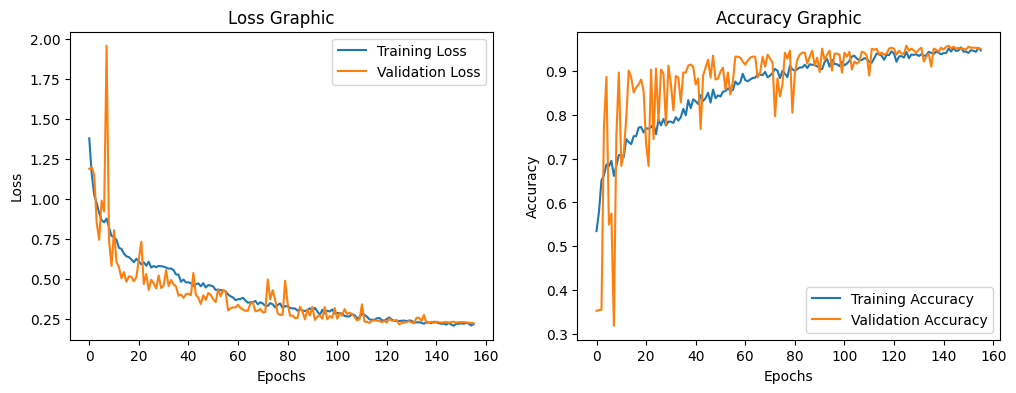

In [41]:
# Plotando o histórico de treinamento após o treinamento
os.makedirs(f"{results_dir}/pretrained", exist_ok=True)
met_vil.plot_training_history(history_pretrained, f"{results_dir}/pretrained", 'pre_training_adni_training_history.png')

### PREDIÇÃO VALIDAÇÃO PRE TREINO

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

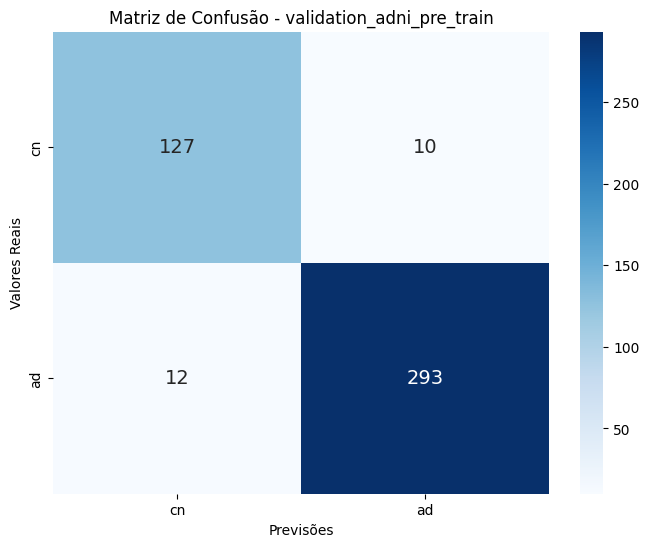

In [42]:
# Realizar predições para dados do conjunto validação
val_pred_labels, val_true_labels, val_pred = met_vil.get_predictions(val_images, val_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels, val_pred_labels, f"{results_dir}/pretrained", 'validation_adni_pre_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels, val_pred_labels, f"{results_dir}/pretrained", 'validation_adni_pre_train', ["cn", "ad"])

# Criar pdf com predições
val_pdf_path = os.path.join(f"{results_dir}/pretrained", "validation_adni_predictions_pre_train.pdf")
met_vil.create_pdf(val_paths, val_images, val_true_labels, val_pred_labels, val_pred, val_pdf_path, ["cn", "ad"])

### PREDIÇÃO TESTE PRE TREINO

Passo 1: Coletando lista de arquivos...
Total de 227 imagens planejadas (incluindo aumentos).
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 227 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/227...
Processado 100/227...
Processado 150/227...
Processado 200/227...
Passo 4: Carregamento concluído.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1

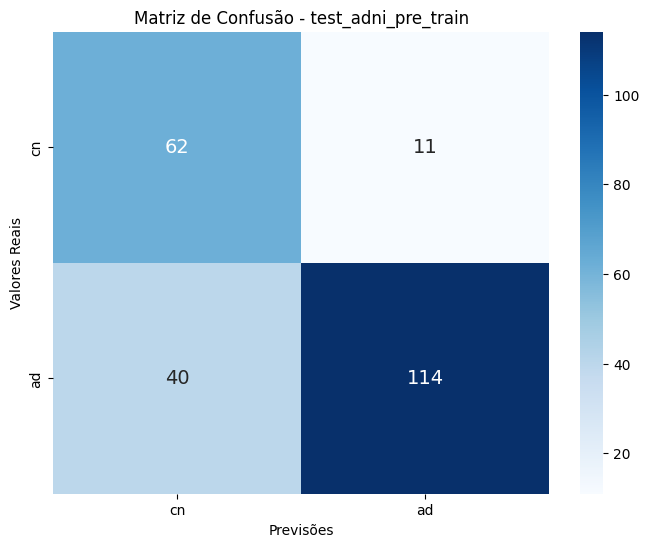

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/cnn/utils/metricas_e_visualizacao.py:119: RuntimeWarning: invalid value encountered in divide
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/cnn/utils/metricas_e_visualizacao.py:119: RuntimeWarning: invalid value encountered in cast
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter


In [43]:
test_images, test_labels, test_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(test_dir, adni_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = met_vil.get_predictions(test_images, test_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels, test_pred_labels, f"{results_dir}/pretrained", 'test_adni_pre_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels, test_pred_labels, f"{results_dir}/pretrained", 'test_adni_pre_train', ["cn", "ad"])

# Criar pdf com predições
test_pdf_path = os.path.join(f"{results_dir}/pretrained", "test_adni_predictions_pre_train.pdf")
met_vil.create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, ["cn", "ad"])

# Transfer learning

In [44]:
# LIMPAR DADOS
del train_images
del train_labels
del train_paths
del val_images
del val_labels
del val_paths
gc.collect()

4604

In [45]:
train_images_fine_tunning, train_labels_fine_tunning, train_paths_fine_tunning, class_labels_fine_tunning = proc_dados.load_nifti_data_balanced_preallocated(
    fine_tunning_train_dir, 
    oasis_class_names, 
    augment=False
)

print(f"N treino: {len(train_images_fine_tunning)}")

val_images_fine_tunning, val_labels_fine_tunning, val_paths_fine_tunning, _ = proc_dados.load_nifti_data_balanced_preallocated(
    fine_tunning_val_dir, 
    oasis_class_names, 
    augment=False
)

print(f"N validatio antes: {len(val_paths_fine_tunning)}")

val_images_fine_tunning, test_images_fine_tunning, val_labels_fine_tunning, test_labels_fine_tunning, val_paths_fine_tunning, test_paths_fine_tunning = train_test_split(
    val_images_fine_tunning, 
    val_labels_fine_tunning, 
    val_paths_fine_tunning, 
    train_size=0.6, 
    test_size=0.4, 
    random_state=42
)

print(f"N validation depois: {len(val_paths_fine_tunning)}")
print(f"N teste: {len(test_paths_fine_tunning)}")

Passo 1: Coletando lista de arquivos...
Total de 164 imagens planejadas (incluindo aumentos).
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 164 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/164...
Processado 100/164...
Processado 150/164...
Passo 4: Carregamento concluído.
N treino: 164
Passo 1: Coletando lista de arquivos...
Total de 69 imagens planejadas (incluindo aumentos).
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 69 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/69...
Passo 4: Carregamento concluído.
N validatio antes: 69
N validation depois: 41
N teste: 28


In [46]:
fase_atual = 2
print("--- INICIANDO FASE 2: FINE-TUNING ---")

# CARREGA O MODELO DA FASE 1
if not os.path.exists(PATH_PRETREINADO):
    raise FileNotFoundError(f"Modelo pré-treinado não encontrado em {PATH_PRETREINADO}. Rode a Fase 1 primeiro.")

print(f"Carregando pesos de: {PATH_PRETREINADO}")
base_model = load_model(PATH_PRETREINADO)

# --- CONGELAMENTO E ADAPTAÇÃO ---
# 1. Remover a camada de classificação antiga e adicionar uma nova (ADnetEx)
# Pega a saída da camada anterior à última
x = base_model.layers[-2].output 

# Adiciona nova camada de classificação inicializada aleatoriamente
predictions = layers.Dense(n_oasis_classes, activation='softmax', name='new_output')(x)

model = models.Model(inputs=base_model.input, outputs=predictions)

# 2. Congelar camadas iniciais (Freezing)
# Vamos congelar as primeiras 7 camadas (aprox. o primeiro bloco convolucional)
for layer in model.layers[:7]:
    layer.trainable = False
    print(f"Camada congelada: {layer.name}")

# 3. Recompilar
# Usar mesmo learning_rate do pre_treino
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                loss='binary_crossentropy', 
                metrics=['binary_accuracy'])

model.summary()

--- INICIANDO FASE 2: FINE-TUNING ---
Carregando pesos de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/fine_tunning_oasis/test_2/modelo_pretrained.keras
Camada congelada: input_layer_2
Camada congelada: conv3d_6
Camada congelada: batch_normalization_8
Camada congelada: leaky_re_lu_8
Camada congelada: average_pooling3d_6
Camada congelada: dropout_8
Camada congelada: conv3d_7


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_6 (Conv3D)               │ (None, 156, 195, 160,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 156, 195, 160,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 156, 195, 160,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_6             │ (None, 52, 65, 54, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 52, 65, 54, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_7 (Conv3D)               │ (None, 52, 65, 54, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 52, 65, 54, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 52, 65, 54, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_7             │ (None, 18, 22, 18, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 18, 22, 18, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_8 (Conv3D)               │ (None, 18, 22, 18, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 18, 22, 18, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 18, 22, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_8             │ (None, 6, 8, 6, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6, 8, 6, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │        73,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             

 Total params: 78,410 (306.29 KB)

 Trainable params: 77,330 (302.07 KB)

 Non-trainable params: 1,080 (4.22 KB)

In [47]:
batch_size = 10

steps_per_epoch = math.ceil(len(train_images_fine_tunning) / batch_size)
validation_steps = math.ceil(len(val_images_fine_tunning) / batch_size)

train_generator_fine_tunning = proc_dados.nifti_data_generator_3d(train_images_fine_tunning, train_labels_fine_tunning, batch_size)
val_generator_fine_tunning = proc_dados.nifti_data_generator_3d(val_images_fine_tunning, val_labels_fine_tunning, batch_size)

# Callbacks
csv_filename = 'log_treino_fase2.csv'
checkpoint_path = PATH_FINETUNED

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=30, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, verbose=1),
    CSVLogger(os.path.join(results_dir, csv_filename)),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_binary_accuracy', save_best_only=True, mode='max')
]

In [50]:
epochs = 100 # Fine-tuning geralmente requer menos épocas

print(f"Iniciando treinamento FASE {fase_atual} por {epochs} épocas...")

history_fine_tunning = model.fit(
    train_generator_fine_tunning,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator_fine_tunning,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

Iniciando treinamento FASE 2 por 100 épocas...
Epoch 1/100
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - binary_accuracy: 0.4492 - loss: 1.1005

2026-01-08 16:16:39.969209: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=6,k13=0,k14=2,k18=0,k23=0} for conv (f16[4,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[4,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-08 16:16:40.203068: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.233900414s
Trying algorithm eng10{k2=6,k13=0,k14=2,k18=0,k23=0} for conv (f16[4,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[4,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_

17/17 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - binary_accuracy: 0.5366 - loss: 0.9256 - val_binary_accuracy: 0.3902 - val_loss: 1.8231 - learning_rate: 5.0000e-04
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - binary_accuracy: 0.7195 - loss: 0.7021 - val_binary_accuracy: 0.3600 - val_loss: 3.1489 - learning_rate: 5.0000e-04
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - binary_accuracy: 0.7622 - loss: 0.6268 - val_binary_accuracy: 0.4200 - val_loss: 2.5579 - learning_rate: 5.0000e-04
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - binary_accuracy: 0.7683 - loss: 0.5495 - val_binary_accuracy: 0.5610 - val_loss: 1.7717 - learning_rate: 5.0000e-04
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - binary_accuracy: 0.8902 - loss: 0.4300 - val_binary_accuracy: 0.5610 - val_loss: 1.4381 - learning_rate: 5.0000e-04
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - binary_accuracy: 0.8598 - loss: 0.4255 - val_binary_accuracy: 0.6098 - val_loss: 1.1142 - learning_rate: 5.00

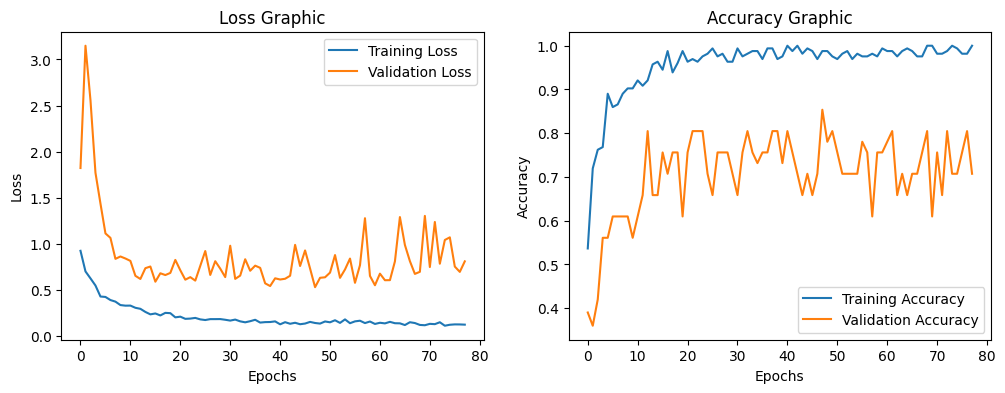

In [51]:
# Plotando o histórico de treinamento após o treinamento
os.makedirs(f"{results_dir}/final", exist_ok=True)
met_vil.plot_training_history(history_fine_tunning, f"{results_dir}/final", "fine_tunning_oasis_training_history.png")

### PREDIÇÃO VALIDAÇÃO

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
              precision    recall  f1-score   support

           0       0.82      0.54      0.65        26
           1       0.50      0.80      0.62        15

    accuracy                           0.63        41
   macro avg       0.66      0.67      0.63        41
weighted avg       0.71      0.63      0.64        41



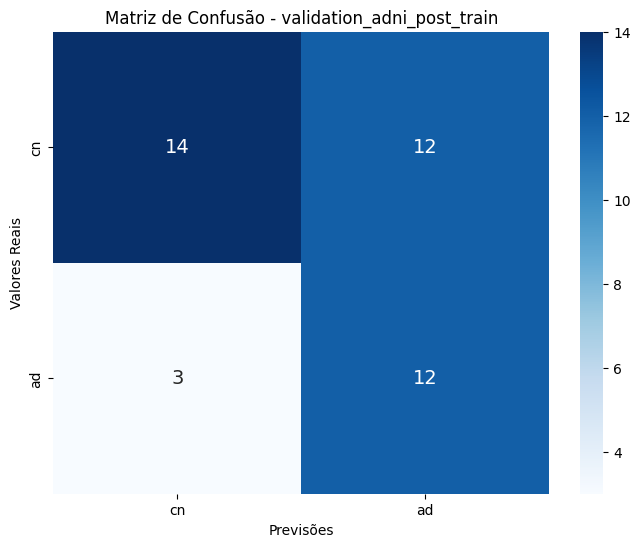

In [52]:
# Realizar predições para dados do conjunto validação
val_pred_labels_post_train, val_true_labels_post_train, val_pred_post_train = met_vil.get_predictions(val_images_fine_tunning, val_labels_fine_tunning, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels_post_train, val_pred_labels_post_train, f"{results_dir}/final", 'validation_adni_post_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels_post_train, val_pred_labels_post_train, f"{results_dir}/final", 'validation_adni_post_train', ["cn", "ad"])

# Criar pdf com predições
val_pdf_path_post_train = os.path.join(f"{results_dir}/final", "validation_adni_predictions_post_train.pdf")
met_vil.create_pdf(val_paths_fine_tunning, val_images_fine_tunning, val_true_labels_post_train, val_pred_labels_post_train, val_pred_post_train, val_pdf_path_post_train, ["cn", "ad"])

### PREDIÇÃO TESTE

Passo 1: Coletando lista de arquivos...
Total de 227 imagens planejadas (incluindo aumentos).
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 227 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/227...
Processado 100/227...
Processado 150/227...
Processado 200/227...
Passo 4: Carregamento concluído.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

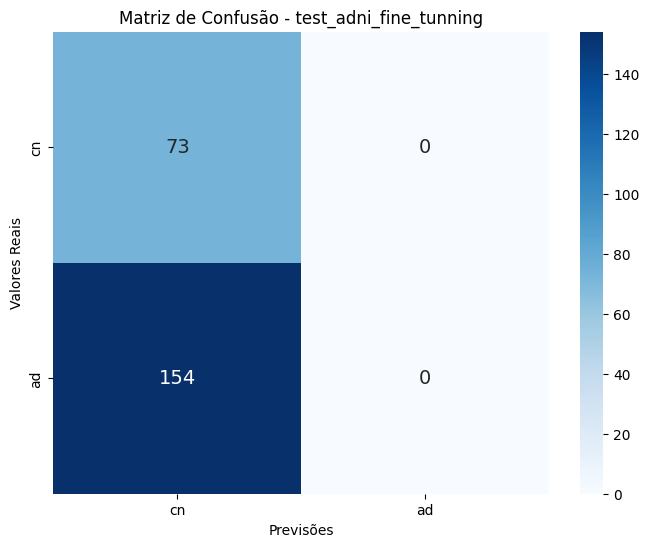

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/cnn/utils/metricas_e_visualizacao.py:119: RuntimeWarning: invalid value encountered in divide
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/cnn/utils/metricas_e_visualizacao.py:119: RuntimeWarning: invalid value encountered in cast
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter


In [53]:
test_images_, test_labels_, test_paths_, _ = proc_dados.load_nifti_data_balanced_preallocated(test_dir, adni_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels_fine_tunning, test_true_labels_fine_tunning, test_pred = met_vil.get_predictions(test_images_, test_labels_, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels_fine_tunning, test_pred_labels_fine_tunning, f"{results_dir}/final", 'test_adni_fine_tunning')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels_fine_tunning, test_pred_labels_fine_tunning, f"{results_dir}/final", 'test_adni_fine_tunning', ["cn", "ad"])

# Criar pdf com predições
test_pdf_path_fine_tunning = os.path.join(f"{results_dir}/final", "test_adni_predictions_fine_tunning.pdf")
met_vil.create_pdf(test_paths_, test_images_, test_true_labels, test_pred_labels, test_pred, test_pdf_path, ["cn", "ad"])

### PREDIÇÃO OASIS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

           0       0.64      0.64      0.64        14
           1       0.64      0.64      0.64        14

    accuracy                           0.64        28
   macro avg       0.64      0.64      0.64        28
weighted avg       0.64      0.64      0.64        28



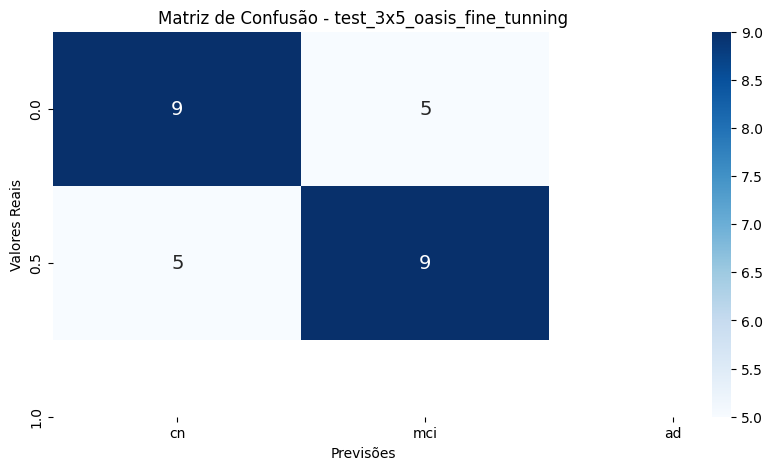

In [54]:
# Realizar predições para dados do conjunto validação
oasis_pred_labels, oasis_true_labels, oasis_pred = met_vil.get_predictions(test_images_fine_tunning, test_labels_fine_tunning, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(oasis_true_labels, oasis_pred_labels, f"{results_dir}/final", 'test_oasis_fine_tunning')

# Obter matriz de confusão
cm_adjusted = confusion_matrix(oasis_true_labels, oasis_pred_labels)
met_vil.plot_custom_confusion_matrix(cm_adjusted, oasis_class_names, adni_class_names, f"{results_dir}/final", 'test_3x5_oasis_fine_tunning')

# # all_possible_numeric_labels = [0.0, 0.5, 1.0, 2.0, 3.0]

# cm_3x3_adjusted = confusion_matrix(oasis_true_labels, gathered_oasis_pred)[0:3, 0:3]

# # Chame a nova função para plotar a matriz ajustada (3x5)
# plot_custom_confusion_matrix(cm_3x3_adjusted, oasis_class_names, oasis_class_names, f"{results_dir}/final", 'test_3x3_oasis_fine_tunning')

# # Criar pdf com predições
oasis_pdf_path = os.path.join(f"{results_dir}/final", "test_oasis_predictions_fine_tunning.pdf")
# create_pdf(oasis_paths, oasis_images, oasis_true_labels, gathered_oasis_pred, oasis_pred, oasis_pdf_path, oasis_class_names)
met_vil.create_pdf(test_paths_fine_tunning, test_images_fine_tunning, oasis_true_labels, oasis_true_labels, oasis_pred, oasis_pdf_path, oasis_class_names)